In addition to traditional machine learning methods, Gramian Angular Field (GAF) transformation and CNN architectures were explored to investigate whether image-based representations of tabular medical data could improve classification performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from pyts.image import GramianAngularField

In [2]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

In [4]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [5]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 0,
    'B': 1
})

In [6]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.627417,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,1.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


CLASS DISTRIBUTION

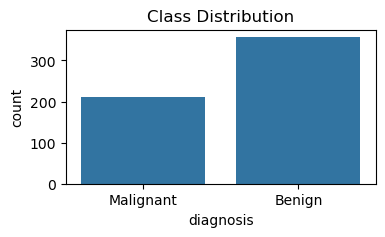

In [8]:
plt.figure(figsize=(4,2))

sns.countplot(x='diagnosis', data=df)

plt.title("Class Distribution")
plt.xticks([0,1], ['Malignant', 'Benign'])

plt.show()

In [9]:
selected_features = [
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean'
]

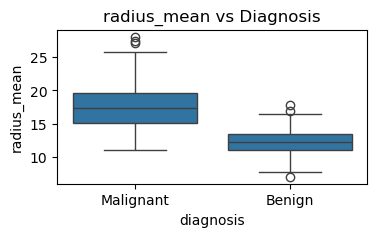

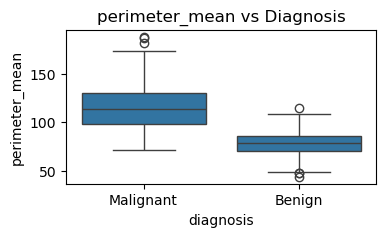

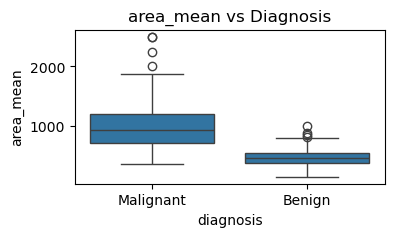

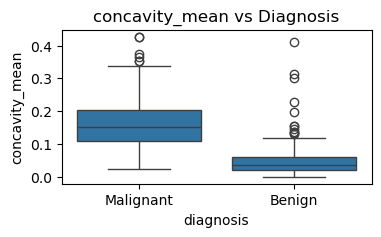

In [10]:
for feature in selected_features:

    plt.figure(figsize=(4,2))

    sns.boxplot(
        x='diagnosis',
        y=feature,
        data=df
    )

    plt.title(f'{feature} vs Diagnosis')

    plt.xticks([0,1], ['Malignant', 'Benign'])

    plt.show()

Malignant tumors tend to exhibit:
 -larger size
 -higher perimeter
 -greater area
 -more irregular boundaries
-The selected clinical features demonstrate clear distributional differences between malignant and benign tumors, indicating strong predictive potential for machine learning classification models.

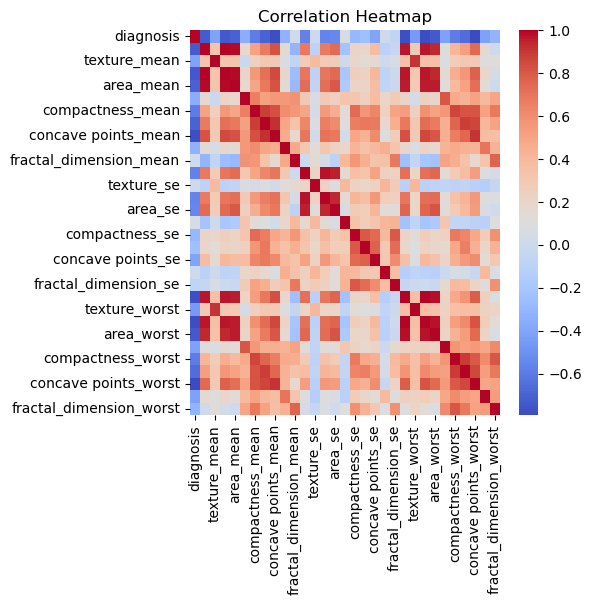

In [11]:
plt.figure(figsize=(5,5))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

 Highly correlated feature groups may create meaningful.
 Visual patterns after GAF transformation.
 Potentially helping CNN models capture spatial relationships.
Highly correlated features may contribute to meaningful pattern formation in GAF-transformed representations, potentially supporting CNN-based feature learning.

In [12]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION

In [15]:
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [16]:
y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

In [17]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(y_test, y_pred_lr)

lr_recall = recall_score(y_test, y_pred_lr)

lr_f1 = f1_score(y_test, y_pred_lr)

lr_auc = roc_auc_score(y_test, y_prob_lr)

In [18]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



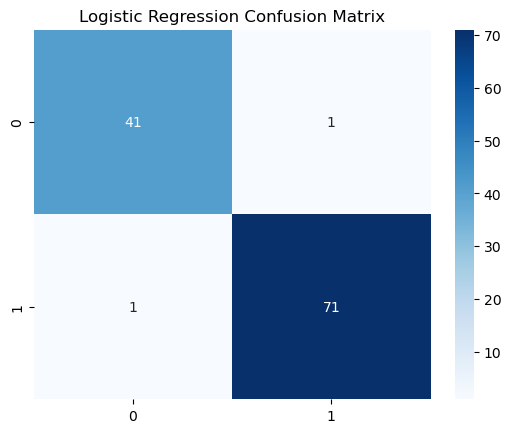

In [19]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.show()

The confusion matrix shows that the Logistic Regression model achieved highly accurate classification results. Most benign and malignant samples were correctly classified, with only two total misclassifications. The low false negative rate indicates strong sensitivity for detecting malignant tumors, which is particularly important in medical diagnosis tasks.

SVM MODEL

In [20]:
svm_model = SVC(
    probability=True
)

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True)

In [21]:
y_pred_svm = svm_model.predict(X_test_scaled)

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

In [22]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(y_test, y_pred_svm)

svm_recall = recall_score(y_test, y_pred_svm)

svm_f1 = f1_score(y_test, y_pred_svm)

svm_auc = roc_auc_score(y_test, y_prob_svm)

In [23]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



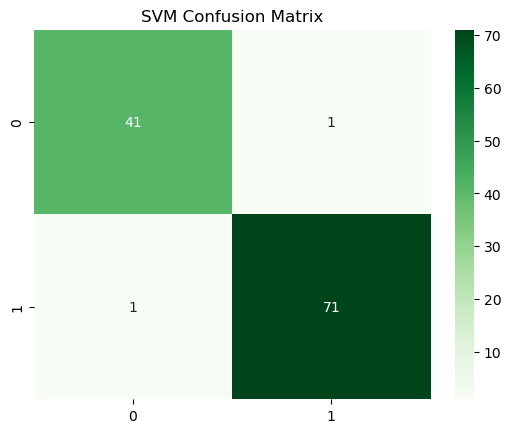

In [24]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("SVM Confusion Matrix")

plt.show()

The confusion matrix shows that the SVM model achieved excellent classification performance with only two misclassified samples. Most benign and malignant tumors were correctly identified, indicating strong sensitivity and reliable diagnostic capability for breast cancer classification.

RANDOM FOREST

In [25]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [26]:
y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

In [27]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

rf_auc = roc_auc_score(y_test, y_prob_rf)

In [28]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



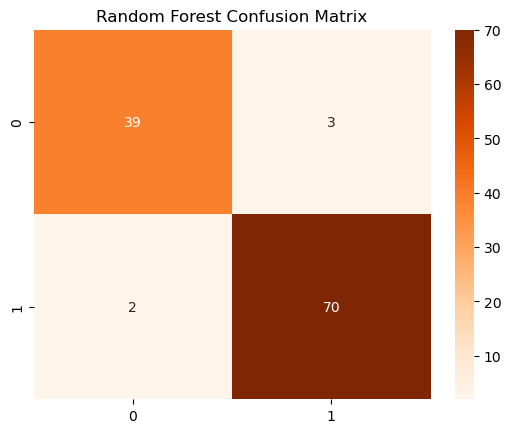

In [29]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title("Random Forest Confusion Matrix")

plt.show()

The confusion matrix shows that the Random Forest model achieved strong classification performance with relatively few misclassifications. Most benign and malignant tumors were correctly identified, although the model produced slightly more classification errors compared to Logistic Regression and SVM models.

GRADIENT BOOSTING

In [30]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier()

In [31]:
y_pred_gb = gb_model.predict(X_test_scaled)

y_prob_gb = gb_model.predict_proba(X_test_scaled)[:,1]

In [32]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)

gb_precision = precision_score(y_test, y_pred_gb)

gb_recall = recall_score(y_test, y_pred_gb)

gb_f1 = f1_score(y_test, y_pred_gb)

gb_auc = roc_auc_score(y_test, y_prob_gb)

In [33]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



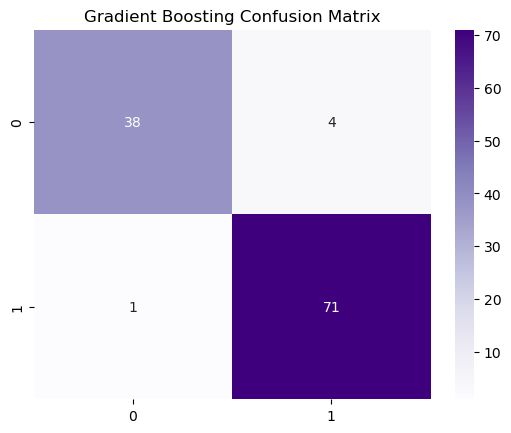

In [34]:
cm = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Gradient Boosting Confusion Matrix")

plt.show()

The confusion matrix shows that the Gradient Boosting model achieved strong classification performance with very few false negative predictions. Most malignant tumors were correctly identified, indicating high sensitivity and reliable diagnostic capability for breast cancer classification.

MODEL COMPARISON TABLE

In [35]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Accuracy': [
        lr_accuracy,
        svm_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    'Precision': [
        lr_precision,
        svm_precision,
        rf_precision,
        gb_precision
    ],

    'Recall': [
        lr_recall,
        svm_recall,
        rf_recall,
        gb_recall
    ],

    'F1 Score': [
        lr_f1,
        svm_f1,
        rf_f1,
        gb_f1
    ],

    'ROC-AUC': [
        lr_auc,
        svm_auc,
        rf_auc,
        gb_auc
    ]
})

In [36]:
results.sort_values(
    by='Recall',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
3,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,0.990741
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993882


ROC CURVE COMPARISON

In [37]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)

svm_fpr, svm_tpr, _ = roc_curve(y_test, y_prob_svm)

rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)

gb_fpr, gb_tpr, _ = roc_curve(y_test, y_prob_gb)

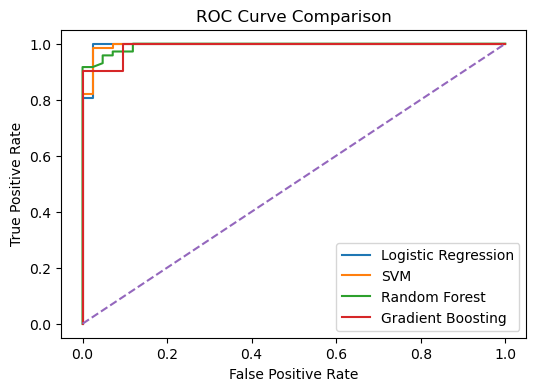

In [38]:
plt.figure(figsize=(6,4))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')

plt.plot(svm_fpr, svm_tpr, label='SVM')

plt.plot(rf_fpr, rf_tpr, label='Random Forest')

plt.plot(gb_fpr, gb_tpr, label='Gradient Boosting')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

-ROC curves compare the ability of different models to distinguish between malignant and benign tumors across multiple classification thresholds.
-All machine learning models achieved strong ROC performance, indicating high discriminative capability between malignant and benign tumor classes. Gradient Boosting and SVM demonstrated particularly strong sensitivity-specificity trade-offs.

THRESHOLD ANALYSIS

In [39]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

In [40]:
for threshold in thresholds:

    y_threshold = (y_prob_rf >= threshold).astype(int)

    recall = recall_score(y_test, y_threshold)

    precision = precision_score(y_test, y_threshold)

    print(f"Threshold: {threshold}")

    print(f"Recall: {recall:.4f}")

    print(f"Precision: {precision:.4f}")

    print("--------------------------")


Threshold: 0.3
Recall: 0.9861
Precision: 0.9342
--------------------------
Threshold: 0.4
Recall: 0.9722
Precision: 0.9589
--------------------------
Threshold: 0.5
Recall: 0.9722
Precision: 0.9589
--------------------------
Threshold: 0.6
Recall: 0.9583
Precision: 0.9718
--------------------------
Threshold: 0.7
Recall: 0.8889
Precision: 1.0000
--------------------------


False negatives are extremely dangerous in breast cancer diagnosis because missing a malignant case may delay treatment and reduce patient survival chances

RANDOM FOREST FEATURE IMPORTANCE

In [41]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_
})

In [42]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

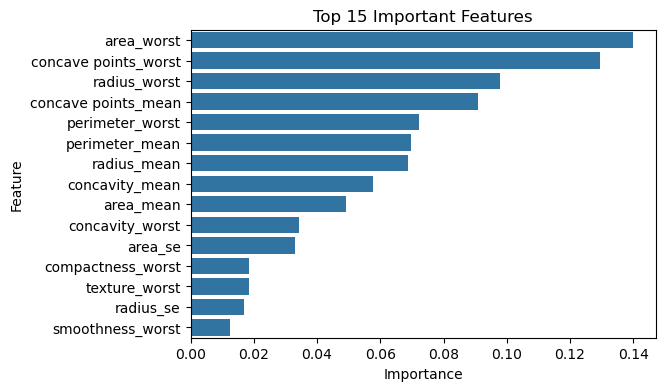

In [43]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

GAF TRANSFORMATION

In [44]:
gaf = GramianAngularField(
    method='summation'
)

In [ ]:
X_train_gaf = gaf.fit_transform(X_train_scaled)

X_test_gaf = gaf.transform(X_test_scaled)

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(X_train_gaf[0], cmap='rainbow')

plt.title("Sample GAF Image")

plt.colorbar()

plt.show()

-GAF transformation converts tabular medical featuresn into image-like representations that preserve feature relationship patterns for CNN learning.
-Converting feature relationships into spatial representations that can be learned by CNN architectures.

In [ ]:
X_train_gaf = X_train_gaf[..., np.newaxis]

X_test_gaf = X_test_gaf[..., np.newaxis]

In [ ]:
cnn_model = models.Sequential([

    layers.Input(shape=(30,30,1)),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = cnn_model.fit(

    X_train_gaf,
    y_train,

    epochs=50,

    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop]
)

In [ ]:
cnn_prob = cnn_model.predict(X_test_gaf)

In [ ]:
cnn_pred = (cnn_prob > 0.5).astype(int)

In [ ]:
cnn_accuracy = accuracy_score(y_test, cnn_pred)

cnn_precision = precision_score(y_test, cnn_pred)

cnn_recall = recall_score(y_test, cnn_pred)

cnn_f1 = f1_score(y_test, cnn_pred)

cnn_auc = roc_auc_score(y_test, cnn_prob)

In [ ]:
print(classification_report(y_test, cnn_pred))

In [ ]:
cm = confusion_matrix(y_test, cnn_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("CNN Confusion Matrix")

plt.show()

-Confusion matrix helps evaluate the types of classification errors, particularly false negatives, which are critical in cancer diagnosis.
-The confusion matrix indicates that the CNN model achieved strong benign tumor classification performance while still misclassifying several malignant cases.
-In medical diagnosis tasks, these false negatives are particularly important because undetected malignant tumors may lead to delayed clinical intervention.

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Learning Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

-Training and validation loss curves are used to monitor CNN learning behavior and detect possible overfitting.
-The CNN model demonstrated stable learning behavior during training, with validation loss decreasing during early epochs before stabilizing. This suggests that the GAF-transformed representations contain meaningful patterns, although mild overfitting may occur due to the limited dataset size.

In [ ]:
cnn_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest',
        'Gradient Boosting',
        'CNN + GAF'
    ],

    'Accuracy': [
        lr_accuracy,
        svm_accuracy,
        rf_accuracy,
        gb_accuracy,
        cnn_accuracy
    ],

    'Precision': [
        lr_precision,
        svm_precision,
        rf_precision,
        gb_precision,
        cnn_precision
    ],

    'Recall': [
        lr_recall,
        svm_recall,
        rf_recall,
        gb_recall,
        cnn_recall
    ],

    'F1 Score': [
        lr_f1,
        svm_f1,
        rf_f1,
        gb_f1,
        cnn_f1
    ],

    'ROC-AUC': [
        lr_auc,
        svm_auc,
        rf_auc,
        gb_auc,
        cnn_auc
    ]
})

In [ ]:
cnn_results.sort_values(
    by='Recall',
    ascending=False
)


Project Limitations:
1. Small dataset size
2. Possible overfitting in CNN model
3. Experimental image transformation approach
4. No real clinical validation
5. Results should not be considered medical advice


This project is intended for educational and decision-support purposes only
and should not be considered a certified medical diagnostic system.

Conclusion:
Traditional machine learning models achieved very strong results
for breast cancer classification.

The CNN + GAF approach demonstrated that image-based representations
of tabular medical data can also produce competitive performance.

Recall was prioritized because missing malignant tumors
can have severe clinical consequences.
